# 01-Finance Tutorial-Portfolio Optimization 

In [1]:
# This code is from:
# https://qiskit-community.github.io/qiskit-finance/tutorials/01_portfolio_optimization.html

# Modified for Quantum Rings SDK

In [2]:
#
# Setup your account
# You can also save your account locally using the class method QrRuntimeService.save_account(...) and
# invoke the QrRuntimeService class constructor without any arguments.
#

import os

my_token = os.environ["QR_TOKEN"]
my_name = os.environ["QR_ACCOUNT"]


#
# Set the backend of your choice, depending upon the task and your hardware configuration.
# See SDK documentation for additional help.
#

my_backend = "scarlet_quantum_rings"

In [3]:
from qiskit.circuit.library import TwoLocal
from qiskit.result import QuasiDistribution
#from qiskit_aer.primitives import Sampler
from qiskit_algorithms import NumPyMinimumEigensolver, QAOA, SamplingVQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit_finance.applications.optimization import PortfolioOptimization
from qiskit_finance.data_providers import RandomDataProvider
from qiskit_optimization.algorithms import MinimumEigenOptimizer
import numpy as np
import matplotlib.pyplot as plt
import datetime

In [4]:
# set number of assets (= number of qubits)
num_assets = 4
seed = 123

# Generate expected return and covariance matrix from (random) time-series
stocks = [("TICKER%s" % i) for i in range(num_assets)]
data = RandomDataProvider(
    tickers=stocks,
    start=datetime.datetime(2016, 1, 1),
    end=datetime.datetime(2016, 1, 30),
    seed=seed,
)
data.run()
mu = data.get_period_return_mean_vector()
sigma = data.get_period_return_covariance_matrix()

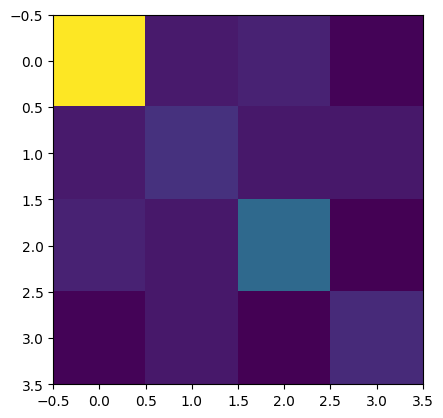

In [5]:
# plot sigma
plt.imshow(sigma, interpolation="nearest")
plt.show()

In [6]:
q = 0.5  # set risk factor
budget = num_assets // 2  # set budget
penalty = num_assets  # set parameter to scale the budget penalty term

portfolio = PortfolioOptimization(
    expected_returns=mu, covariances=sigma, risk_factor=q, budget=budget
)
qp = portfolio.to_quadratic_program()
qp

<QuadraticProgram: minimize 0.001270694296030004*x_0^2 + 7.34022166934733e-05*..., 4 variables, 1 constraints, 'Portfolio optimization'>

In [7]:
def print_result(result):
    selection = result.x
    value = result.fval
    print("Optimal: selection {}, value {:.4f}".format(selection, value))

    eigenstate = result.min_eigen_solver_result.eigenstate

    if (isinstance(eigenstate, dict)):    
        probabilities = (
            eigenstate.binary_probabilities()
            if isinstance(eigenstate, QuasiDistribution)
            else {k: np.abs(v) ** 2 for k, v in eigenstate.items()}
        )
    else:
        probabilities = (
            eigenstate.binary_probabilities()
            if isinstance(eigenstate, QuasiDistribution)
            else {k: np.abs(v) ** 2 for k, v in eigenstate.to_dict().items()}
        )
        
    print("\n----------------- Full result ---------------------")
    print("selection\tvalue\t\tprobability")
    print("---------------------------------------------------")
    probabilities = sorted(probabilities.items(), key=lambda x: x[1], reverse=True)

    for k, v in probabilities:
        x = np.array([int(i) for i in list(reversed(k))])
        value = portfolio.to_quadratic_program().objective.evaluate(x)
        print("%10s\t%.4f\t\t%.4f" % (x, value, v))

In [8]:
exact_mes = NumPyMinimumEigensolver()
exact_eigensolver = MinimumEigenOptimizer(exact_mes)

result = exact_eigensolver.solve(qp)

print_result(result)

Optimal: selection [1. 0. 0. 1.], value -0.0149

----------------- Full result ---------------------
selection	value		probability
---------------------------------------------------
 [1 0 0 1]	-0.0149		1.0000


In [9]:
from quantumrings.toolkit.qiskit import QrRuntimeService
from quantumrings.toolkit.qiskit import QrSamplerV2 as Sampler

#
# Acquire Quantum Rings Backend
#

qr_services = QrRuntimeService(name = my_name, token = my_token)
qr_backend = qr_services.backend(name = my_backend, precision = "single")

In [10]:
from qiskit_algorithms.utils import algorithm_globals

algorithm_globals.random_seed = 1234

cobyla = COBYLA()
cobyla.set_options(maxiter=500)
ry = TwoLocal(num_assets, "ry", "cz", reps=3, entanglement="full")
svqe_mes = SamplingVQE(sampler=Sampler(backend = qr_backend), ansatz=ry, optimizer=cobyla)
svqe = MinimumEigenOptimizer(svqe_mes)
result = svqe.solve(qp)

print_result(result)

Optimal: selection [1. 0. 0. 1.], value -0.0149

----------------- Full result ---------------------
selection	value		probability
---------------------------------------------------
 [1 0 0 1]	-0.0149		0.8054
 [0 1 1 0]	0.0008		0.0022
 [1 0 1 0]	-0.0140		0.0003
 [0 0 1 1]	-0.0010		0.0002
 [1 1 1 0]	-0.0130		0.0001
 [1 1 0 0]	-0.0130		0.0000
 [0 1 0 1]	0.0002		0.0000
 [1 0 0 0]	-0.0140		0.0000
 [0 0 1 0]	-0.0001		0.0000
 [0 0 0 0]	0.0000		0.0000


In [11]:
algorithm_globals.random_seed = 1234

cobyla = COBYLA()
cobyla.set_options(maxiter=250)
qaoa_mes = QAOA(sampler=Sampler(backend = qr_backend), optimizer=cobyla, reps=3)
qaoa = MinimumEigenOptimizer(qaoa_mes)
result = qaoa.solve(qp)

print_result(result)

Optimal: selection [1. 0. 0. 1.], value -0.0149

----------------- Full result ---------------------
selection	value		probability
---------------------------------------------------
 [1 0 1 0]	-0.0140		0.0133
 [1 0 0 1]	-0.0149		0.0107
 [1 1 0 0]	-0.0130		0.0103
 [0 0 1 1]	-0.0010		0.0084
 [0 1 0 1]	0.0002		0.0076
 [0 1 1 0]	0.0008		0.0054
 [1 1 0 1]	-0.0139		0.0042
 [1 0 0 0]	-0.0140		0.0038
 [1 1 1 0]	-0.0130		0.0035
 [1 0 1 1]	-0.0150		0.0032
 [0 1 0 0]	0.0009		0.0027
 [0 0 1 0]	-0.0001		0.0021
 [0 0 0 1]	-0.0008		0.0015
 [0 1 1 1]	-0.0000		0.0014
 [1 1 1 1]	-0.0139		0.0000
 [0 0 0 0]	0.0000		0.0000


In [12]:
import tutorial_magics

%qiskit_version_table
%quantumrings_version_table
%qiskit_copyright

Software,Version
QuantumRingsLib,0.11.0
quantumrings-toolkit-qiskit,0.1.20
